In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

df = pd.read_csv("../data/processed/rossmann_base.csv", parse_dates=["Date"])
df.shape


C:\Users\TestAdmin\AppData\Local\Temp\ipykernel_31248\2854638647.py:7: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/rossmann_base.csv", parse_dates=["Date"])


(844392, 22)

In [3]:
drop_cols = [
    "Date",        # temporal index, not a predictor directly
    "Customers"   # data leakage
]

df_fe = df.drop(columns=drop_cols)
df_fe.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month',
       'Week', 'Day'],
      dtype='object')

In [4]:
X = df_fe.drop(columns=["Sales"])
y = df_fe["Sales"]

X.shape, y.shape

((844392, 19), (844392,))

In [5]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols, numerical_cols

(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'],
 ['Store',
  'DayOfWeek',
  'Open',
  'Promo',
  'SchoolHoliday',
  'CompetitionDistance',
  'CompetitionOpenSinceMonth',
  'CompetitionOpenSinceYear',
  'Promo2',
  'Promo2SinceWeek',
  'Promo2SinceYear',
  'Year',
  'Month',
  'Week',
  'Day'])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

X_train.shape, X_test.shape

((675513, 19), (168879, 19))

In [7]:
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)

# Align test set to train set columns
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

In [8]:
num_cols_enc = X_train_enc.select_dtypes(include=["int64", "float64"]).columns

imputer = SimpleImputer(strategy="median")

X_train_enc[num_cols_enc] = imputer.fit_transform(X_train_enc[num_cols_enc])
X_test_enc[num_cols_enc] = imputer.transform(X_test_enc[num_cols_enc])

In [9]:
X_train_enc.isnull().sum().sum(), X_test_enc.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [10]:
X_train_enc.to_csv("../data/processed/X_train.csv", index=False)
X_test_enc.to_csv("../data/processed/X_test.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

In [ ]:
# ===============================
# Feature Selection: Correlation
# ===============================

import pandas as pd
import matplotlib.pyplot as plt

df_corr = pd.get_dummies(df_fe, drop_first=True)
correlation = df_corr.corr()['Sales'].sort_values(ascending=False)

correlation.head(10)

Sales              1.000000
Promo              0.368145
StoreType_b        0.144608
Assortment_c       0.103280
Promo2SinceWeek    0.095311
Week               0.074472
Month              0.073600
StateHoliday_0     0.055732
Assortment_b       0.053755
SchoolHoliday      0.038617
Name: Sales, dtype: float64

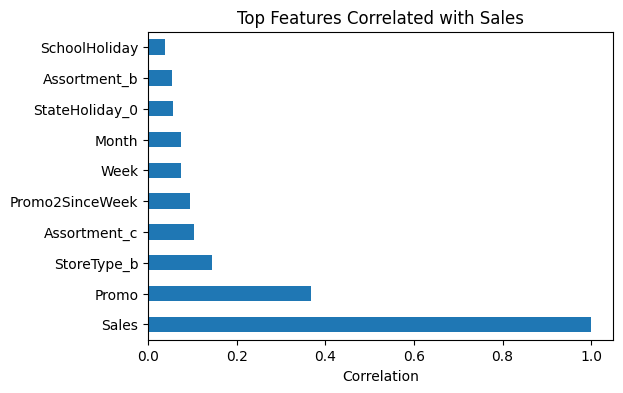

In [12]:
correlation.head(10).plot(kind='barh', figsize=(6,4))
plt.title('Top Features Correlated with Sales')
plt.xlabel('Correlation')
plt.show()

In [13]:
from sklearn.ensemble import RandomForestRegressor

X = pd.get_dummies(df_fe.drop(columns=['Sales']), drop_first=True)
y = df_fe['Sales']

rf_fs = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_fs.fit(X.sample(30000, random_state=42), y.sample(30000, random_state=42))

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_fs.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
3,Promo,0.250080
5,CompetitionDistance,0.166971
0,Store,0.086414
1,DayOfWeek,0.084785
6,CompetitionOpenSinceMonth,0.055166
13,Week,0.051223
9,Promo2SinceWeek,0.049276
19,StoreType_b,0.047344
23,Assortment_c,0.044143
7,CompetitionOpenSinceYear,0.041775


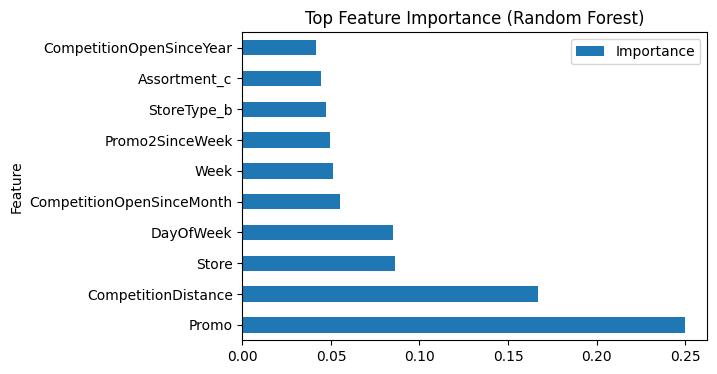

In [14]:
feature_importance.head(10).plot(
    kind='barh',
    x='Feature',
    y='Importance',
    figsize=(6,4)
)

plt.title('Top Feature Importance (Random Forest)')
plt.show()

Feature Selection Decision

Feature selection was performed using correlation analysis with the target variable and feature importance from a Random Forest model.

Promotional variables, store characteristics, and temporal features consistently showed strong influence on sales.

Final Decision: All engineered features were retained except Date and Customers, which were excluded to prevent data leakage. Tree-based models were chosen as they handle feature interactions and multicollinearity effectively.